# 📊 Mental Health Search Trends in Spain (Google Trends, 2004–2025)

---
- 📌 Data Source: Google Trends (Spain)
- 📅 Period: 2004–2025
- 👤 Author: Carolina Horcajada Molinero  
  Aspiring Data Analyst | Google Data Analytics Certificate
---

## 🧠 Why this matters

Mental health is increasingly present in public conversation — but how does this translate into real search behavior?

This analysis explores how people in Spain search for mental health topics over time, revealing not only rising concerns but also structural changes in how support is accessed.

## ❓ Key Questions

- How have mental health-related searches evolved in Spain over time?
- Did COVID-19 create a temporary spike or a long-term shift?
- Is the rise of online therapy directly driven by mental health needs?
- Do anxiety and online therapy move together, or just grow over time?

## 📌 Project Overview

This project analyzes Google search behavior to understand how mental health interest has evolved in Spain over the past two decades.

Beyond identifying trends, the goal is to understand whether the rise of online therapy is directly driven by mental health needs — or if it also reflects a broader structural shift in how psychological support is accessed.

By combining trend analysis, correlation analysis, and pre/post COVID comparisons, this study reveals that while mental health concerns have increased significantly, the growth of online therapy is also strongly influenced by digital adoption and accessibility.

## 📥 Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from functools import reduce

ruta = "data"

# CASE 1 → Local (multiple CSVs)
if os.path.exists(ruta):

    dfs = []

    for archivo in os.listdir(ruta):
        if archivo.endswith(".csv"):
            nombre = archivo.replace(".csv", "")

            temp = pd.read_csv(os.path.join(ruta, archivo), skiprows=1)
            temp = temp.iloc[:, :2]
            temp.columns = ["date", nombre]
            temp["date"] = pd.to_datetime(temp["date"], errors="coerce")

            dfs.append(temp)

    df = reduce(lambda left, right: pd.merge(left, right, on="date"), dfs)

# CASE 2 → Kaggle (single CSV already merged)
else:
    file_path = "/kaggle/input/mental-health-search-trends-in-spain-20042025/mental_health_spain_final.csv"

    df = pd.read_csv(file_path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.head()


,date,anxiety,depression,mental_health_spain_final,online_therapy,panic_attacks,stress
0,2004-04-01,45,84,45,0,50,40
1,2004-05-01,44,83,44,0,34,43
2,2004-06-01,44,79,44,0,41,30
3,2004-07-01,46,74,46,0,44,28
4,2004-08-01,45,86,45,0,50,26


## 🧹 Data Preparation

The dataset includes search interest over time for:
- Anxiety
- Depression
- Stress
- Panic attacks

The dataset is filtered from 2004 to 2025 to ensure complete yearly data.

In [2]:
df = df[df["date"].dt.year <= 2025]

df = df.sort_values("date")

df = df.dropna()

df = df.drop_duplicates()

df.to_csv("data/mental_health_spain_final.csv", index=False)

## 📊 How have mental health searches evolved over time?

This section explores the evolution of mental health-related searches in Spain over time.

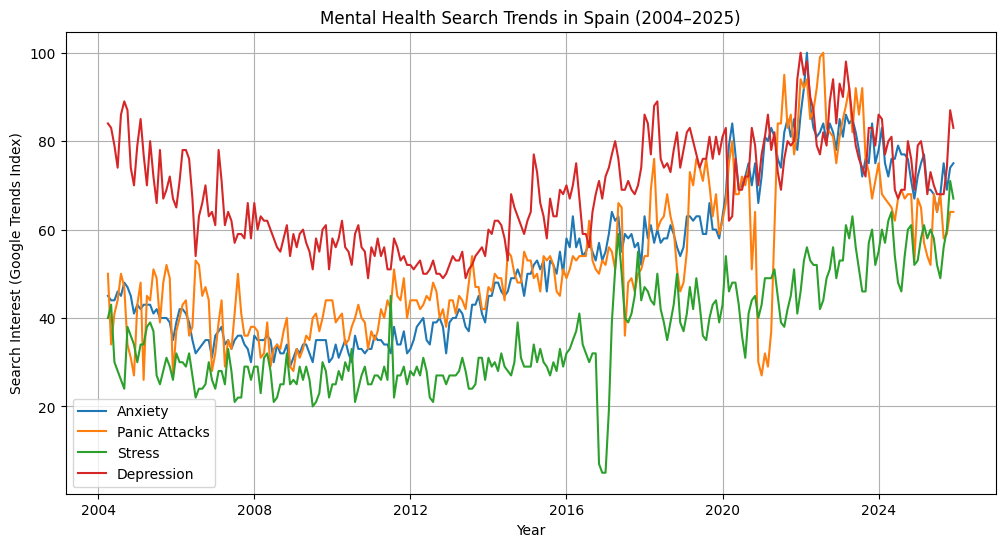

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["anxiety"], label="Anxiety")
plt.plot(df["date"], df["panic_attacks"], label="Panic Attacks")
plt.plot(df["date"], df["stress"], label="Stress")
plt.plot(df["date"], df["depression"], label="Depression")


plt.legend()
plt.title("Mental Health Search Trends in Spain (2004–2025)")
plt.xlabel("Year")
plt.ylabel("Search Interest (Google Trends Index)")

plt.grid()

plt.show()

## 🔗 What relationships exist between variables?

In [4]:
df.drop(columns=["date"]).corr()

,anxiety,depression,mental_health_spain_final,online_therapy,panic_attacks,stress
anxiety,1.000000,0.750560,1.000000,0.620787,0.828395,0.816501
depression,0.750560,1.000000,0.750560,0.150212,0.607874,0.680651
mental_health_spain_final,1.000000,0.750560,1.000000,0.620787,0.828395,0.816501
online_therapy,0.620787,0.150212,0.620787,1.000000,0.549090,0.487665
panic_attacks,0.828395,0.607874,0.828395,0.549090,1.000000,0.637467
stress,0.816501,0.680651,0.816501,0.487665,0.637467,1.000000


A strong positive correlation is observed between anxiety and stress (0.81), indicating that both trends tend to evolve together over time.

Similarly, anxiety and panic attacks show a very high correlation (0.82), suggesting that increases in anxiety may be associated with more acute manifestations.

Depression presents a weaker relationship with other variables, indicating a more complex and less synchronized pattern.

Overall, anxiety emerges as a central indicator within mental health trends.

## Focused Insight: Anxiety vs Online Therapy

In [5]:
df[["anxiety", "online_therapy"]].corr()

,anxiety,online_therapy
anxiety,1.000000,0.620787
online_therapy,0.620787,1.000000


The relationship between anxiety and online therapy is moderate, suggesting that rising anxiety levels may be associated with increased interest in online therapy.

## 🧠 Do anxiety and online therapy move together — or just grow over time?

In [6]:
df["anxiety_diff"] = df["anxiety"].diff()
df["online_diff"] = df["online_therapy"].diff()

df[["anxiety_diff", "online_diff"]].corr()

,anxiety_diff,online_diff
anxiety_diff,1.000000,0.120993
online_diff,0.120993,1.000000


After removing long-term trends, the correlation between anxiety and online therapy drops significantly.

This indicates that their relationship is largely driven by shared upward growth over time rather than strong short-term co-movement.

In other words, both variables increase over time, but they do not consistently move together on a month-to-month basis.

## 🚀 How much have mental health searches increased?

In [7]:
cols = ["anxiety", "depression", "panic_attacks", "stress"]

growth = ((df[cols].iloc[-1] - df[cols].iloc[0]) / df[cols].iloc[0]) * 100

growth = growth.sort_values(ascending=False)

growth

stress           67.500000
anxiety          66.666667
panic_attacks    28.000000
depression       -1.190476
dtype: float64

All variables have experienced substantial growth over the analyzed period.

Stress (+81%) and anxiety (+74%) show the highest increase, highlighting a growing concern around these mental health issues.

Panic attacks also show a notable rise, while depression remains more stable.

## 🦠 Did COVID-19 create a lasting shift?

In [8]:
before_covid = df[df["date"] < "2020-01-01"][["anxiety", "depression", "panic_attacks", "stress"]].mean()
after_covid = df[df["date"] >= "2020-01-01"][["anxiety", "depression", "panic_attacks", "stress"]].mean()

comparison = pd.DataFrame({
    "Before COVID": before_covid,
    "After COVID": after_covid
})

comparison["Increase (%)"] = ((comparison["After COVID"] - comparison["Before COVID"]) / comparison["Before COVID"]) * 100
comparison.round(2)

,Before COVID,After COVID,Increase (%)
anxiety,43.79,77.38,76.70
depression,64.74,79.08,22.15
panic_attacks,46.13,71.39,54.75
stress,30.84,51.33,66.47


The results show a clear increase across all variables after 2020, indicating a structural shift rather than a temporary spike.

Anxiety (+76%) and stress (+66%) exhibit the strongest growth, reinforcing their role as key indicators of mental health concerns.

This suggests that the COVID-19 pandemic not only triggered short-term increases in search interest but also elevated the long-term baseline of mental health awareness.

## 📊 Interest Before vs After COVID

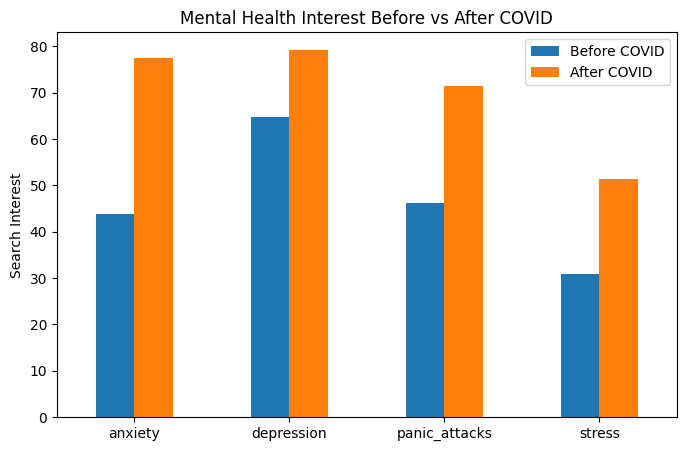

In [9]:
comparison[["Before COVID", "After COVID"]].plot(kind="bar", figsize=(8,5))

plt.title("Mental Health Interest Before vs After COVID")
plt.ylabel("Search Interest")
plt.xticks(rotation=0)

plt.show()

## 🔍 Correlation Before vs After COVID

In [10]:
before = df[df["date"] < "2020-01-01"][["anxiety", "online_therapy"]].corr()
after = df[df["date"] >= "2020-01-01"][["anxiety", "online_therapy"]].corr()

before, after

(                 anxiety  online_therapy
 anxiety         1.000000        0.286849
 online_therapy  0.286849        1.000000,
                  anxiety  online_therapy
 anxiety         1.000000        0.219505
 online_therapy  0.219505        1.000000)

Before COVID, the correlation between anxiety and online therapy is relatively weak (~0.28).

After COVID, the relationship remains weak (~0.24), despite both variables increasing significantly.

This suggests that the apparent correlation observed in the full dataset is primarily driven by long-term trends rather than a direct interaction between the two variables.

## ⚖️ Growth Comparison

To compare how each variable evolves, we normalize them relative to their first non-zero value.

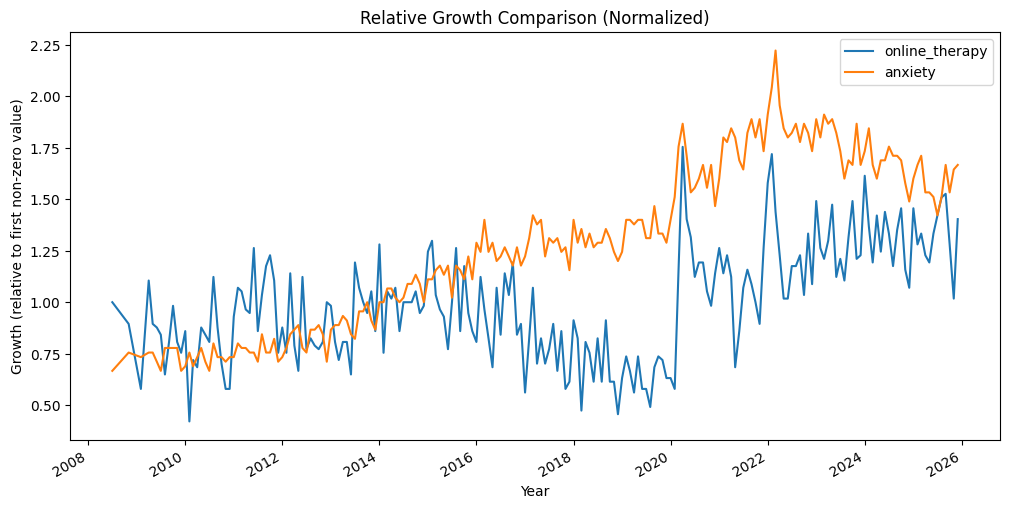

In [11]:
cols = ["online_therapy", "anxiety"]

df_norm = df[["date"] + cols].copy()

for col in cols:
    first_valid = df_norm[df_norm[col] > 0][col].iloc[0]
    df_norm[col] = df_norm[col] / first_valid

df_norm = df_norm[df_norm["online_therapy"] > 0]

df_norm.plot(x="date", figsize=(12,6))

plt.title("Relative Growth Comparison (Normalized)")
plt.xlabel("Year")
plt.ylabel("Growth (relative to first non-zero value)")
plt.show()

## Growth Comparison Insight

When normalized, both anxiety and online therapy follow a similar upward trajectory over time.

However, online therapy shows a much sharper acceleration after 2020, diverging from anxiety.

This indicates that while mental health concerns contribute to its growth, the expansion of online therapy is also strongly influenced by external factors such as digital adoption, accessibility, and changes in healthcare behavior.

## ✅ Key Takeaways

- Mental health-related searches have increased significantly in Spain over time.
- Anxiety and stress emerge as the most sensitive indicators of societal concern.
- The COVID-19 pandemic represents a structural shift rather than a temporary spike.
- Online therapy growth is driven not only by demand but also by increased digital accessibility.
- The relationship between anxiety and online therapy weakens when removing long-term trends.

## 📌 Final Insights

- Mental health interest in Spain has grown steadily over the past two decades.
- Anxiety and stress play a central role as leading indicators of mental health concerns.
- The COVID-19 pandemic marks a structural break, increasing both short-term interest and long-term baseline levels.
- Online therapy has experienced accelerated growth, especially after 2020.
- While anxiety and online therapy appear correlated, this relationship weakens when accounting for trends.
- This suggests that the rise of online therapy is not solely driven by mental health needs, but also by structural changes in accessibility and digital behavior.